Pre-Modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
races = pd.read_csv("../data/races.csv")
results = pd.read_csv("../data/results.csv")
drivers = pd.read_csv("../data/drivers.csv")
constructors = pd.read_csv("../data/constructors.csv")
circuits = pd.read_csv("../data/circuits.csv")
qualifying = pd.read_csv("../data/qualifying.csv")

In [3]:
print(races.head())
print(results.head())
print(drivers.head())
print(constructors.head())

   raceId  year  round  circuitId                   name        date  \
0       1  2009      1          1  Australian Grand Prix  2009-03-29   
1       2  2009      2          2   Malaysian Grand Prix  2009-04-05   
2       3  2009      3         17     Chinese Grand Prix  2009-04-19   
3       4  2009      4          3     Bahrain Grand Prix  2009-04-26   
4       5  2009      5          4     Spanish Grand Prix  2009-05-10   

       time                                                url fp1_date  \
0  06:00:00  http://en.wikipedia.org/wiki/2009_Australian_G...       \N   
1  09:00:00  http://en.wikipedia.org/wiki/2009_Malaysian_Gr...       \N   
2  07:00:00  http://en.wikipedia.org/wiki/2009_Chinese_Gran...       \N   
3  12:00:00  http://en.wikipedia.org/wiki/2009_Bahrain_Gran...       \N   
4  12:00:00  http://en.wikipedia.org/wiki/2009_Spanish_Gran...       \N   

  fp1_time fp2_date fp2_time fp3_date fp3_time quali_date quali_time  \
0       \N       \N       \N       \N       

In [4]:
print("Races:", races.shape)
print("Results:", results.shape)
print("Drivers:", drivers.shape)
print("Constructors:", constructors.shape)

Races: (1125, 18)
Results: (26759, 18)
Drivers: (861, 9)
Constructors: (212, 5)


Data-Mergering

In [5]:

df = results.merge(races, on="raceId", how="left")
df = df.merge(drivers, on="driverId", how="left")
df = df.merge(constructors, on="constructorId", how="left", suffixes=("", "_constructor"))
df = df.merge(circuits, on="circuitId", how="left", suffixes=("", "_circuit"))

DATA-CLEANING

In [6]:


df["driver_name"] = df["forename"] + " " + df["surname"]

df = df.rename(columns={
    "name": "race_name",
    "name_constructor": "constructor_name",
    "name_circuit": "circuit_name"
})

f1 = df[[
    "year",
    "race_name",
    "circuit_name",
    "driver_name",
    "constructor_name",
    "grid",
    "positionOrder",
    "points",
    "laps",
    "statusId"
]].copy()

f1.head()

,year,race_name,circuit_name,driver_name,constructor_name,grid,positionOrder,points,laps,statusId
0,2008,Australian Grand Prix,Albert Park Grand Prix Circuit,Lewis Hamilton,McLaren,1,1,10.0,58,1
1,2008,Australian Grand Prix,Albert Park Grand Prix Circuit,Nick Heidfeld,BMW Sauber,5,2,8.0,58,1
2,2008,Australian Grand Prix,Albert Park Grand Prix Circuit,Nico Rosberg,Williams,7,3,6.0,58,1
3,2008,Australian Grand Prix,Albert Park Grand Prix Circuit,Fernando Alonso,Renault,11,4,5.0,58,1
4,2008,Australian Grand Prix,Albert Park Grand Prix Circuit,Heikki Kovalainen,McLaren,3,5,4.0,58,1


Feature Engineering

In [7]:


f1["top_10"] = f1["positionOrder"].apply(lambda x: 1 if x <= 10 else 0)
f1["podium"] = f1["positionOrder"].apply(lambda x: 1 if x <= 3 else 0)
f1["win"] = f1["positionOrder"].apply(lambda x: 1 if x == 1 else 0)

f1.head()

,year,race_name,circuit_name,driver_name,constructor_name,grid,positionOrder,points,laps,statusId,top_10,podium,win
0,2008,Australian Grand Prix,Albert Park Grand Prix Circuit,Lewis Hamilton,McLaren,1,1,10.0,58,1,1,1,1
1,2008,Australian Grand Prix,Albert Park Grand Prix Circuit,Nick Heidfeld,BMW Sauber,5,2,8.0,58,1,1,1,0
2,2008,Australian Grand Prix,Albert Park Grand Prix Circuit,Nico Rosberg,Williams,7,3,6.0,58,1,1,1,0
3,2008,Australian Grand Prix,Albert Park Grand Prix Circuit,Fernando Alonso,Renault,11,4,5.0,58,1,1,0,0
4,2008,Australian Grand Prix,Albert Park Grand Prix Circuit,Heikki Kovalainen,McLaren,3,5,4.0,58,1,1,0,0


Exploratory Data Analysis

In [8]:
#Top 10 Driver Berdasarkan Points

driver_points = (
    f1.groupby("driver_name")["points"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

driver_points

driver_name
Lewis Hamilton        4820.5
Sebastian Vettel      3098.0
Max Verstappen        2912.5
Fernando Alonso       2329.0
Kimi Räikkönen        1873.0
Valtteri Bottas       1788.0
Nico Rosberg          1594.5
Sergio Pérez          1585.0
Michael Schumacher    1566.0
Charles Leclerc       1363.0
Name: points, dtype: float64

In [9]:
#Top 10 Constructor Berdasarkan Points
constructor_points = (
    f1.groupby("constructor_name")["points"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

constructor_points

constructor_name
Ferrari        11091.27
Mercedes        7730.64
Red Bull        7673.00
McLaren         7022.50
Williams        3641.00
Renault         1777.00
Force India     1098.00
Team Lotus       995.00
Benetton         861.50
Tyrrell          711.00
Name: points, dtype: float64

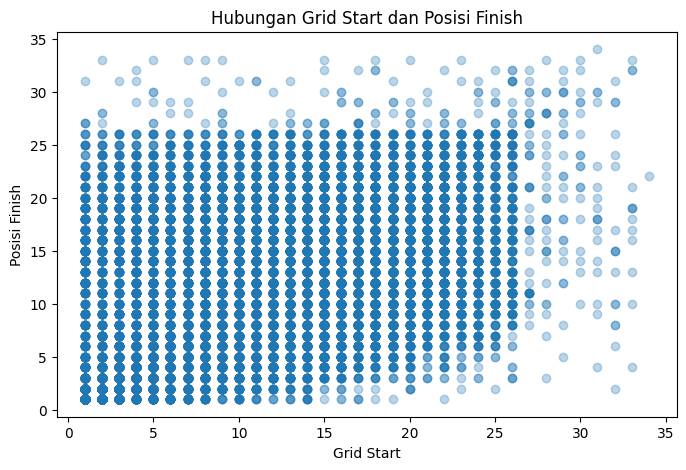

In [10]:
#Hubungan Grid Start dan Posisi Finish
grid_finish = f1[["grid", "positionOrder"]].copy()
grid_finish = grid_finish[grid_finish["grid"] > 0]

plt.figure(figsize=(8,5))
plt.scatter(grid_finish["grid"], grid_finish["positionOrder"], alpha=0.3)
plt.title("Hubungan Grid Start dan Posisi Finish")
plt.xlabel("Grid Start")
plt.ylabel("Posisi Finish")
plt.show()

Pre-Data Modeling

In [11]:

model_data = f1[[
    "year",
    "grid",
    "constructor_name",
    "circuit_name",
    "top_10"
]].copy()

model_data = model_data.dropna()
model_data = model_data[model_data["grid"] > 0]

X = model_data[["year", "grid", "constructor_name", "circuit_name"]]
y = model_data["top_10"]

Model Training

In [12]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [17]:
categorical_features = ["constructor_name", "circuit_name"]
numeric_features = ["year", "grid"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=30,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Model-Evaluation

In [15]:


y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6845771144278607
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      2797
           1       0.65      0.62      0.64      2228

    accuracy                           0.68      5025
   macro avg       0.68      0.68      0.68      5025
weighted avg       0.68      0.68      0.68      5025



In [18]:
# TAHAP 11 — SIMPAN MODEL

import joblib

joblib.dump(model, "model.pkl", compress=3)
print("Model berhasil disimpan sebagai model.pkl")

Model berhasil disimpan sebagai model.pkl
